In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
wb = 1.2  # cavity frequency
w = 0.8  # atomic frequency
g = 0.6  # atom-cavity coupling
gamma = 0.07  # cavity empting raate
gamma_a = 0.06  # atomic spontaneous emission rate
N = 10  # photon number

wx = 0.6
D = 0.4

t_max = 100.0
dt = 0.05
steps = int(t_max / dt)
t_list = np.linspace(0, t_max, steps)

In [4]:
#let's define the operators in the basis |spin_z, n>
sz = np.array([[1, 0], [0, -1]])
sp = np.array([[0, 1], [0, 0]])
sm = np.array([[0, 0], [1, 0]])

b = np.zeros((N + 1, N + 1))
for i in range(1, N + 1):
    b[i - 1, i] = np.sqrt(i)

b_dag = b.conj().T

b_num = b_dag @ b

Ia = np.eye(2)
If = np.eye(N+1)

H = w/2 * np.kron(sz, If) + wb * np.kron(Ia, b_num) + g * (np.kron(sp, b) + np.kron(sm, b_dag))

# define lindblad operators
b_tot = np.kron(Ia, b)
b_tot_dag = b_tot.conj().T
b_num_tot = np.kron(Ia, b_num)

sm_tot = np.kron(sm, If)
sp_tot = np.kron(sp, If)
s_num = np.kron(sp@sm, If)

def Lind(rho, H):
    L1 = gamma * b_tot @ rho @ b_tot_dag - gamma/2 * (b_num_tot @ rho + rho @ b_num_tot)
    L2 = gamma_a * sm_tot @ rho @ sp_tot - gamma_a/2 * (s_num @ rho + rho @ s_num)
    rho_dot = -1j * (H @ rho - rho @ H) + L1 + L2
    return rho_dot

In [5]:
def rk4_step(rho, H, dt):
    k1 = dt * Lind(rho, H)
    k2 = dt * Lind(rho + 0.5*k1, H)
    k3 = dt * Lind(rho + 0.5*k2, H)
    k4 = dt * Lind(rho + k3, H)
    return rho + (k1 + 2*k2 + 2*k3 + k4) / 6.0

In [6]:
# initial condition
rho = np.zeros((2 * (N + 1), 2 * (N + 1)), dtype=complex)
rho[3, 3] = 1.0
rho_0 = rho

n_photons = []
p_excited = []
gs = []

In [7]:
# expectation numbers
for t in t_list:
    n_photons.append(np.real(np.trace(b_num_tot @ rho)))
    p_excited.append(np.real(np.trace(s_num @ rho)))
    gs.append(np.real(rho[N + 1, N + 1]))   # in teoria sarebbe sempre reale ma se esce 0 lo scemo lo considera complesso
    rho = rk4_step(rho, H, dt)

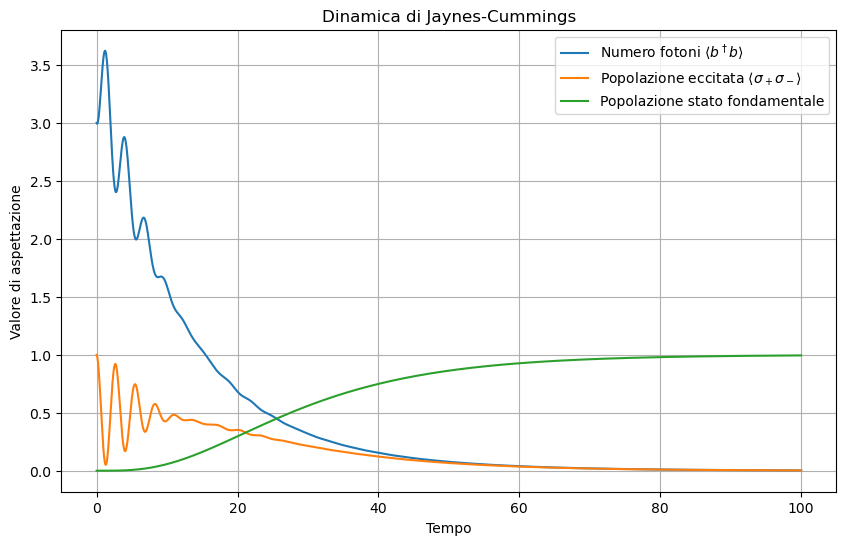

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(t_list, n_photons, label='Numero fotoni $\\langle b^\\dagger b \\rangle$')
plt.plot(t_list, p_excited, label='Popolazione eccitata $\\langle \\sigma_+ \\sigma_- \\rangle$')
plt.plot(t_list, gs, label='Popolazione stato fondamentale')
plt.xlabel('Tempo')
plt.ylabel('Valore di aspettazione')
plt.title('Dinamica di Jaynes-Cummings')
plt.legend()
plt.grid(True)
plt.show()


In [9]:
# let's define driving fields
sx = np.array([[0, 1], [1, 0]])

H_1 = H + wx * np.kron(sx, If)
H_2 = H + D * np.kron(Ia, b + b_dag)
H_3 = H + g * np.kron(sx, b + b_dag)


# initial condition
rho = np.zeros((2 * (N + 1), 2 * (N + 1)), dtype=complex)
rho_1 = rho_0
rho_2 = rho_0
rho_3 = rho_0

n_photons_1 = []
p_excited_1 = []
s_z_1 = []
gs_1 = []

n_photons_2 = []
p_excited_2 = []
s_z_2 = []
gs_2 = []

n_photons_3 = []
p_excited_3 = []
s_z_3 = []
gs_3 = []

In [10]:
# expectation numbers
for t in t_list:
    n_photons_1.append(np.real(np.trace(b_num_tot @ rho_1)))
    p_excited_1.append(np.real(np.trace(s_num @ rho_1)))
    s_z_1.append((np.real(np.trace(s_num @ rho_1))))
    gs_1.append(np.real(rho_1[N + 1, N + 1]))
    rho_1 = rk4_step(rho_1, H_1, dt)

    n_photons_2.append(np.real(np.trace(b_num_tot @ rho_2)))
    p_excited_2.append(np.real(np.trace(s_num @ rho_2)))
    s_z_2.append((np.real(np.trace(s_num @ rho_2))))
    gs_2.append(np.real(rho_2[N + 1, N + 1]))
    rho_2 = rk4_step(rho_2, H_2, dt)

    n_photons_3.append(np.real(np.trace(b_num_tot @ rho_3)))
    p_excited_3.append(np.real(np.trace(s_num @ rho_3)))
    s_z_3.append((np.real(np.trace(s_num @ rho_3))))
    gs_3.append(np.real(rho_3[N + 1, N + 1]))
    rho_3 = rk4_step(rho_3, H_3, dt)

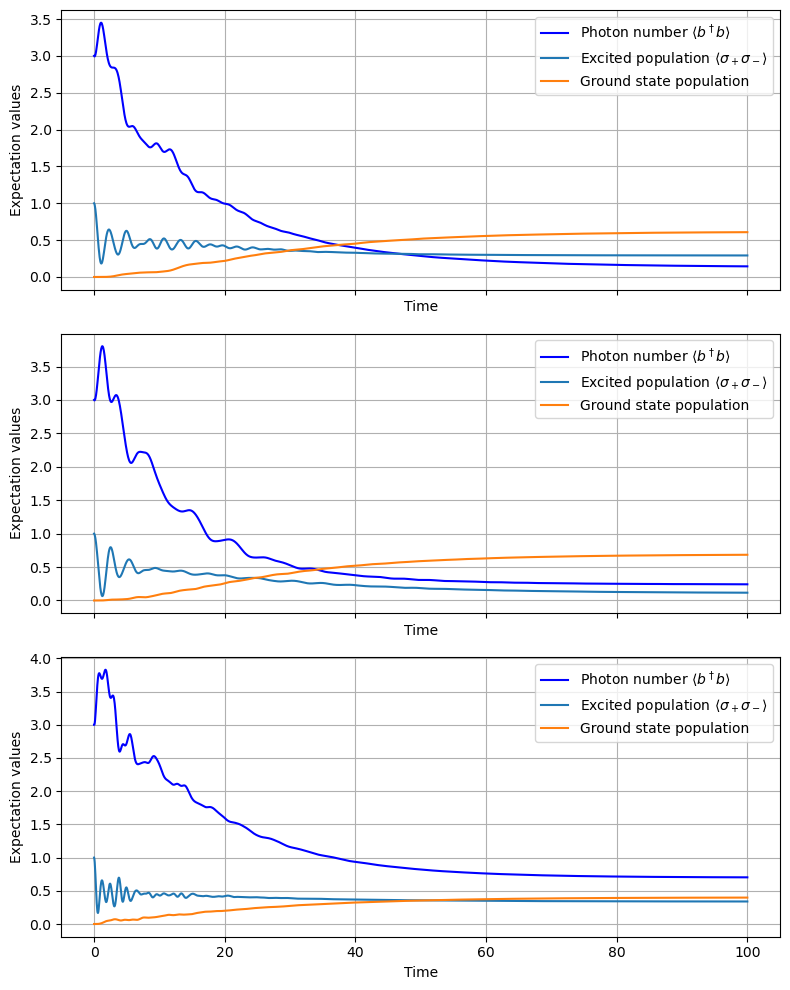

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
ax1.plot(t_list, n_photons_1, color='blue', label='Photon number $\\langle b^\\dagger b \\rangle$')
ax1.plot(t_list, p_excited_1, label='Excited population $\\langle \\sigma_+ \\sigma_- \\rangle$')
ax1.plot(t_list, gs_1, label='Ground state population')
ax1.set_xlabel("Time")
ax1.set_ylabel("Expectation values")
ax1.legend()
ax1.grid(True)

ax2.plot(t_list, n_photons_2, color='blue', label='Photon number $\\langle b^\\dagger b \\rangle$')
ax2.plot(t_list, p_excited_2, label='Excited population $\\langle \\sigma_+ \\sigma_- \\rangle$')
ax2.plot(t_list, gs_2, label='Ground state population')
ax2.set_xlabel("Time")
ax2.set_ylabel("Expectation values")
ax2.legend()
ax2.grid(True)

ax3.plot(t_list, n_photons_3, color='blue', label='Photon number $\\langle b^\\dagger b \\rangle$')
ax3.plot(t_list, p_excited_3, label='Excited population $\\langle \\sigma_+ \\sigma_- \\rangle$')
ax3.plot(t_list, gs_3, label='Ground state population')
ax3.set_xlabel("Time")
ax3.set_ylabel("Expectation values")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()